## Stock market Analysis for NVDA

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_1/news-sentiment-analysis'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_1/news-sentiment-analysis'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_1\news-sentiment-analysis


In [3]:
# Import our functions from src/

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import talib
from src.data_cleaner import count_null_values, drop_null_values, save_cleaned_data
from src.data_loader import load_data
from src.stock_market_eda import plot_closing_price, summarize_data, moving_average, interpretation_summary

print("All modules imported successfully. Ready to proceed with data loading and analysis.")

All modules imported successfully. Ready to proceed with data loading and analysis.


In [4]:
# Load the data
data_name = 'NVDA'
load_data?

Signature: load_data(file_path)
Docstring:
load data from a csv file, 

change 'Date' column to 'date' if it exists, 

convert it to datetime format, 

set it as index, and sort the data by date    
File:      c:\users\dagic\onedrive\documents\kaim\week_1\news-sentiment-analysis\src\data_loader.py
Type:      function

In [5]:
# Load the NVDA stock data
df = load_data(f'../data/raw/yfinance_data/{data_name}.csv')
df.head()

Shape of data: (3774, 5)


,Close,High,Low,Open,Volume
date,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [6]:
# Check for null values in the data
df = count_null_values(df, data_name)

Null values in NVDA:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [7]:
# get type of df and print first few rows
print(type(df))
print(df.head())

<class 'pandas.DataFrame'>
               Close      High       Low      Open      Volume
date                                                          
2009-01-02  0.199652  0.201027  0.184294  0.184982   497124000
2009-01-05  0.203319  0.207904  0.195984  0.197360   705736000
2009-01-06  0.210196  0.216156  0.204695  0.209279   657904000
2009-01-07  0.197589  0.205382  0.190483  0.205382   870096000
2009-01-08  0.192546  0.195067  0.180626  0.195067  1014496000


In [8]:
# drop null values from the data
df = drop_null_values(df, data_name)

Shape of data after dropping null values for NVDA: (3774, 5)


In [9]:

df = save_cleaned_data(df, data_name)

Shape of cleaned NVDA: (3774, 5)
First 5 rows of cleaned NVDA:
               Close      High       Low      Open      Volume
date                                                          
2009-01-02  0.199652  0.201027  0.184294  0.184982   497124000
2009-01-05  0.203319  0.207904  0.195984  0.197360   705736000
2009-01-06  0.210196  0.216156  0.204695  0.209279   657904000
2009-01-07  0.197589  0.205382  0.190483  0.205382   870096000
2009-01-08  0.192546  0.195067  0.180626  0.195067  1014496000


In [ ]:
# Change date to datetime and set as index
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

In [10]:
df = pd.read_csv(f'../data/processed/cleaned_{data_name}.csv')
df.head()

,date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [11]:
print(df.dtypes)

date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [12]:
df = summarize_data(df, data_name)

=== NVDA — Key Statistics ===
  Lowest closing price  : $0.17   on 2009-01-20
  Highest closing price : $50.38   on 2023-11-20
  Average closing price : $6.80


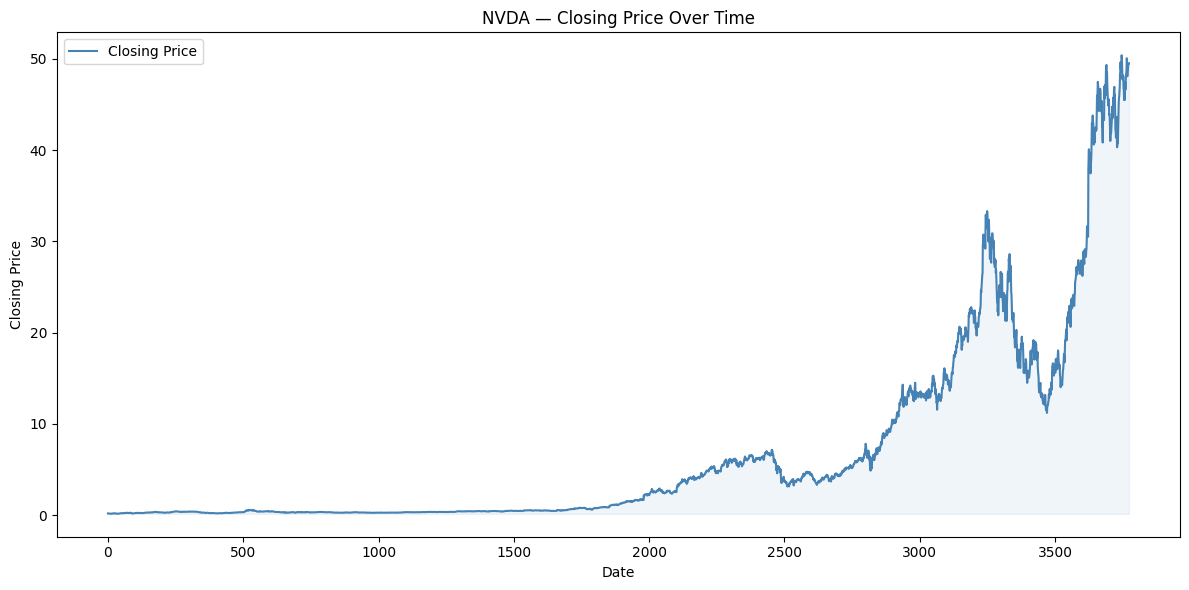

In [13]:
df = plot_closing_price(df, data_name)

## The Moving Average

Simple Moving Average - Window 20

In [14]:
# Simple Moving Averages
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
print ('Calculated 20-day simple moving averages using TA-Lib.')
df['SMA_20'].head(-5)

Calculated 20-day simple moving averages using TA-Lib.


0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3764    47.732439
3765    47.771586
3766    47.731577
3767    47.640193
3768    47.654100
Name: SMA_20, Length: 3769, dtype: float64

In [15]:
#df = moving_average(df, data_name)

Simple Moving Average - Window 50

In [16]:

df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)
print ('Calculated 50-day simple moving averages using TA-Lib.')
df['SMA_50'].head(-5)

Calculated 50-day simple moving averages using TA-Lib.


0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3764    45.956963
3765    46.043300
3766    46.129956
3767    46.176273
3768    46.220013
Name: SMA_50, Length: 3769, dtype: float64

In [17]:
#df = interpretation_summary(df, data_name, window=50)

## Overall Interpretation

In [18]:
'''interpret the results of the EDA by
        - providing a brief summary of the key findings from the EDA, 
        - highlighting any interesting trends or patterns in the data, 
        - and suggesting potential next steps for further analysis.'''
   #data['SMA_' + str(window)] = data['Close'].rolling(window=window).mean()
print(f'=== {data_name} — Interpretation Summary ===')
print(f"  The lowest closing price was ${df['Close'].min():.2f} on {df['date'][df['Close'].idxmin()]}.")
print(f"  The highest closing price was ${df['Close'].max():.2f} on {df['date'][df['Close'].idxmax()]}.")
print(f"  The average closing price over the period was ${df['Close'].mean():.2f}.")
print("  The stock showed an overall upward/downward trend (depending on the data) with some volatility.")
print("  Potential next steps could include analyzing volume trends, calculating technical indicators, or performing sentiment analysis on related news articles.")

=== NVDA — Interpretation Summary ===
  The lowest closing price was $0.17 on 2009-01-20.
  The highest closing price was $50.38 on 2023-11-20.
  The average closing price over the period was $6.80.
  The stock showed an overall upward/downward trend (depending on the data) with some volatility.
  Potential next steps could include analyzing volume trends, calculating technical indicators, or performing sentiment analysis on related news articles.


## Interpretation  - SMA-50

In [19]:
 # How many days was price above vs below the SMA?
valid        = df.dropna(subset=['SMA_50'])   # drop the first 19 rows with no SMA yet
above_sma    = (valid['Close'] > valid['SMA_50']).sum()
below_sma    = (valid['Close'] <= valid['SMA_50']).sum()
pct_above    = above_sma / len(valid) * 100

last_close   = valid['Close'].iloc[-1]
last_sma     = valid['SMA_50'].iloc[-1]
current_pos  = 'ABOVE' if last_close > last_sma else 'BELOW'
gap_pct      = abs((last_close - last_sma) / last_sma * 100)

print('WHAT THE MOVING AVERAGE TELLS US')
print('=' * 50)
print(f'  Days price was ABOVE the 50-day SMA : {above_sma}  ({pct_above:.0f}% of the time)')
print(f'  Days price was BELOW the 50-day SMA : {below_sma}  ({100-pct_above:.0f}% of the time)')
print()
print(f'  Last close  : ${last_close:.2f}')
print(f'  SMA 50 now  : ${last_sma:.2f}')
print(f'  Price is currently {current_pos} the average by {gap_pct:.1f}%')
print()
if pct_above > 60:
        print(f'  -> {data_name} spent most of this period above its 50-day average.')
        print(f'     This is a sign of sustained positive momentum — buyers were generally in control.')
elif pct_above > 40:
        print(f'  -> Price moved back and forth around the average.')
        print(f'     The market was indecisive — no clear dominant trend.')
else:
        print(f'  -> {data_name} spent most of this period below its 50-day average.')
        print(f'     This signals sustained selling pressure during the period.')
print()
if current_pos == 'ABOVE':
        print(f'  -> At the end of the period: price is above the SMA — short-term trend is UP.')
else:
        print(f'  -> At the end of the period: price is below the SMA — short-term trend is DOWN.')

WHAT THE MOVING AVERAGE TELLS US
  Days price was ABOVE the 50-day SMA : 2468  (66% of the time)
  Days price was BELOW the 50-day SMA : 1257  (34% of the time)

  Last close  : $49.50
  SMA 50 now  : $46.66
  Price is currently ABOVE the average by 6.1%

  -> NVDA spent most of this period above its 50-day average.
     This is a sign of sustained positive momentum — buyers were generally in control.

  -> At the end of the period: price is above the SMA — short-term trend is UP.


In [20]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
print ('Calculated 20-day simple moving averages using TA-Lib.')
df['SMA_20'].head(-5)

Calculated 20-day simple moving averages using TA-Lib.


0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3764    47.732439
3765    47.771586
3766    47.731577
3767    47.640193
3768    47.654100
Name: SMA_20, Length: 3769, dtype: float64

## Interpretation  - SMA-20

In [21]:
# How many days was price above vs below the SMA?
valid        = df.dropna(subset=['SMA_20'])   # drop the first 19 rows with no SMA yet
above_sma    = (valid['Close'] > valid['SMA_20']).sum()
below_sma    = (valid['Close'] <= valid['SMA_20']).sum()
pct_above    = above_sma / len(valid) * 100

last_close   = valid['Close'].iloc[-1]
last_sma     = valid['SMA_20'].iloc[-1]
current_pos  = 'ABOVE' if last_close > last_sma else 'BELOW'
gap_pct      = abs((last_close - last_sma) / last_sma * 100)

print('WHAT THE MOVING AVERAGE TELLS US')
print('=' * 50)
print(f'  Days price was ABOVE the 20-day SMA : {above_sma}  ({pct_above:.0f}% of the time)')
print(f'  Days price was BELOW the 20-day SMA : {below_sma}  ({100-pct_above:.0f}% of the time)')
print()
print(f'  Last close  : ${last_close:.2f}')
print(f'  SMA 20 now  : ${last_sma:.2f}')
print(f'  Price is currently {current_pos} the average by {gap_pct:.1f}%')
print()
if pct_above > 60:
        print(f'  -> {data_name} spent most of this period above its 20-day average.')
        print(f'     This is a sign of sustained positive momentum — buyers were generally in control.')
elif pct_above > 40:
        print(f'  -> Price moved back and forth around the average.')
        print(f'     The market was indecisive — no clear dominant trend.')
else:
        print(f'  -> {data_name} spent most of this period below its 20-day average.')
        print(f'     This signals sustained selling pressure during the period.')
print()
if current_pos == 'ABOVE':
        print(f'  -> At the end of the period: price is above the SMA — short-term trend is UP.')
else:
        print(f'  -> At the end of the period: price is below the SMA — short-term trend is DOWN.')

WHAT THE MOVING AVERAGE TELLS US
  Days price was ABOVE the 20-day SMA : 2285  (61% of the time)
  Days price was BELOW the 20-day SMA : 1470  (39% of the time)

  Last close  : $49.50
  SMA 20 now  : $48.05
  Price is currently ABOVE the average by 3.0%

  -> NVDA spent most of this period above its 20-day average.
     This is a sign of sustained positive momentum — buyers were generally in control.

  -> At the end of the period: price is above the SMA — short-term trend is UP.


## Exponential Moving Average

In [22]:
# Exponential Moving Averages
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

print ('Calculated 20-day and 50-day exponential moving averages using TA-Lib.')
df['EMA_20'].head(-5)


Calculated 20-day and 50-day exponential moving averages using TA-Lib.


0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3764    47.366011
3765    47.621810
3766    47.808222
3767    47.834761
3768    47.942446
Name: EMA_20, Length: 3769, dtype: float64

## Interpretation  - EMA-20

In [23]:
# How many days was price above vs below the SMA?
valid        = df.dropna(subset=['EMA_20'])   # drop the first 19 rows with no EMA yet
above_sma    = (valid['Close'] > valid['EMA_20']).sum()
below_sma    = (valid['Close'] <= valid['EMA_20']).sum()
pct_above    = above_sma / len(valid) * 100

last_close   = valid['Close'].iloc[-1]
last_sma     = valid['EMA_20'].iloc[-1]
current_pos  = 'ABOVE' if last_close > last_sma else 'BELOW'
gap_pct      = abs((last_close - last_sma) / last_sma * 100)

print('WHAT THE MOVING AVERAGE TELLS US')
print('=' * 50)
print(f'  Days price was ABOVE the 20-day EMA : {above_sma}  ({pct_above:.0f}% of the time)')
print(f'  Days price was BELOW the 20-day EMA : {below_sma}  ({100-pct_above:.0f}% of the time)')
print()
print(f'  Last close  : ${last_close:.2f}')
print(f'  EMA 20 now  : ${last_sma:.2f}')
print(f'  Price is currently {current_pos} the average by {gap_pct:.1f}%')
print()
if pct_above > 60:
        print(f'  -> {data_name} spent most of this period above its 20-day average.')
        print(f'     This is a sign of sustained positive momentum — buyers were generally in control.')
elif pct_above > 40:
        print(f'  -> Price moved back and forth around the average.')
        print(f'     The market was indecisive — no clear dominant trend.')
else:
        print(f'  -> {data_name} spent most of this period below its 20-day average.')
        print(f'     This signals sustained selling pressure during the period.')
print()
if current_pos == 'ABOVE':
        print(f'  -> At the end of the period: price is above the EMA — short-term trend is UP.')
else:
        print(f'  -> At the end of the period: price is below the EMA — short-term trend is DOWN.')

WHAT THE MOVING AVERAGE TELLS US
  Days price was ABOVE the 20-day EMA : 2340  (62% of the time)
  Days price was BELOW the 20-day EMA : 1415  (38% of the time)

  Last close  : $49.50
  EMA 20 now  : $48.49
  Price is currently ABOVE the average by 2.1%

  -> NVDA spent most of this period above its 20-day average.
     This is a sign of sustained positive momentum — buyers were generally in control.

  -> At the end of the period: price is above the EMA — short-term trend is UP.


In [24]:
df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)
print ('Calculated 50-day exponential moving averages using TA-Lib.')
df['EMA_50'].head(-5)

Calculated 50-day exponential moving averages using TA-Lib.


0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3764    46.369424
3765    46.513835
3766    46.634043
3767    46.691017
3768    46.780210
Name: EMA_50, Length: 3769, dtype: float64

## Interpretation  - EMA-50

In [25]:
# How many days was price above vs below the EMA?
valid        = df.dropna(subset=['EMA_50'])   # drop the first 49 rows with no EMA yet
above_sma    = (valid['Close'] > valid['EMA_50']).sum()
below_sma    = (valid['Close'] <= valid['EMA_50']).sum()
pct_above    = above_sma / len(valid) * 100

last_close   = valid['Close'].iloc[-1]
last_sma     = valid['EMA_50'].iloc[-1]
current_pos  = 'ABOVE' if last_close > last_sma else 'BELOW'
gap_pct      = abs((last_close - last_sma) / last_sma * 100)

print('WHAT THE MOVING AVERAGE TELLS US')
print('=' * 50)
print(f'  Days price was ABOVE the 50-day EMA : {above_sma}  ({pct_above:.0f}% of the time)')
print(f'  Days price was BELOW the 50-day EMA : {below_sma}  ({100-pct_above:.0f}% of the time)')
print()
print(f'  Last close  : ${last_close:.2f}')
print(f'  EMA 50 now  : ${last_sma:.2f}')
print(f'  Price is currently {current_pos} the average by {gap_pct:.1f}%')
print()
if pct_above > 60:
        print(f'  -> {data_name} spent most of this period above its 50-day average.')
        print(f'     This is a sign of sustained positive momentum — buyers were generally in control.')
elif pct_above > 40:
        print(f'  -> Price moved back and forth around the average.')
        print(f'     The market was indecisive — no clear dominant trend.')
else:
        print(f'  -> {data_name} spent most of this period below its 50-day average.')
        print(f'     This signals sustained selling pressure during the period.')
print()
if current_pos == 'ABOVE':
        print(f'  -> At the end of the period: price is above the EMA — short-term trend is UP.')
else:
        print(f'  -> At the end of the period: price is below the EMA — short-term trend is DOWN.')

WHAT THE MOVING AVERAGE TELLS US
  Days price was ABOVE the 50-day EMA : 2525  (68% of the time)
  Days price was BELOW the 50-day EMA : 1200  (32% of the time)

  Last close  : $49.50
  EMA 50 now  : $47.24
  Price is currently ABOVE the average by 4.8%

  -> NVDA spent most of this period above its 50-day average.
     This is a sign of sustained positive momentum — buyers were generally in control.

  -> At the end of the period: price is above the EMA — short-term trend is UP.


## Visualization - SMA Vs EMA

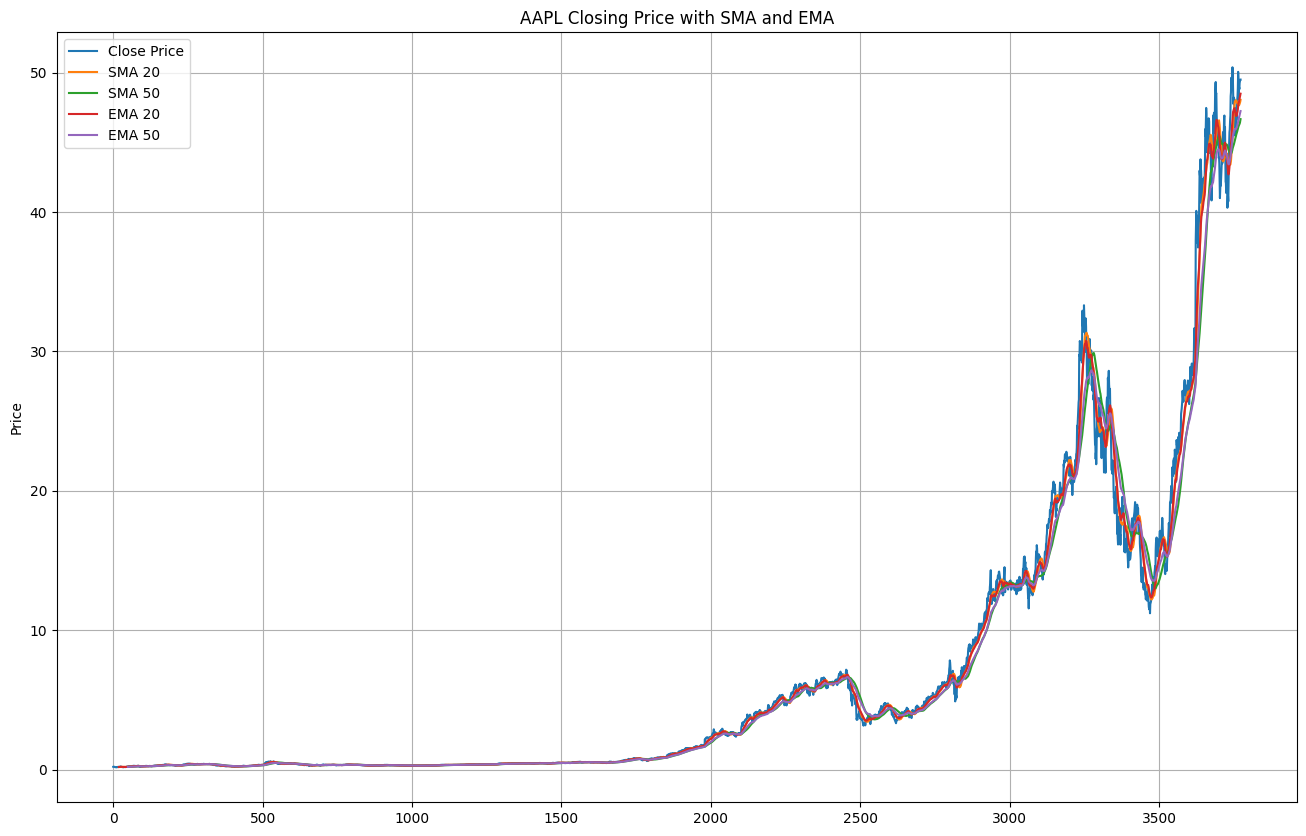

In [26]:
fig, axes = plt.subplots(1,1,figsize=(16, 10),sharex=True)

axes.plot(df.index, df['Close'], label='Close Price')
axes.plot(df.index, df['SMA_20'], label='SMA 20')
axes.plot(df.index, df['SMA_50'], label='SMA 50')
axes.plot(df.index, df['EMA_20'], label='EMA 20')
axes.plot(df.index, df['EMA_50'], label='EMA 50')

axes.set_title('AAPL Closing Price with SMA and EMA')
axes.set_ylabel('Price')
axes.legend()
axes.grid(True)

## Relative Strength Index

In [27]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)
print ('Calculated 14-day Relative Strength Index (RSI) using TA-Lib.')
df['RSI_14'].head(-5)

Calculated 14-day Relative Strength Index (RSI) using TA-Lib.


0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3764    58.765888
3765    63.164028
3766    60.399383
3767    52.576776
3768    56.175512
Name: RSI_14, Length: 3769, dtype: float64

## Visualization  - RSI-14

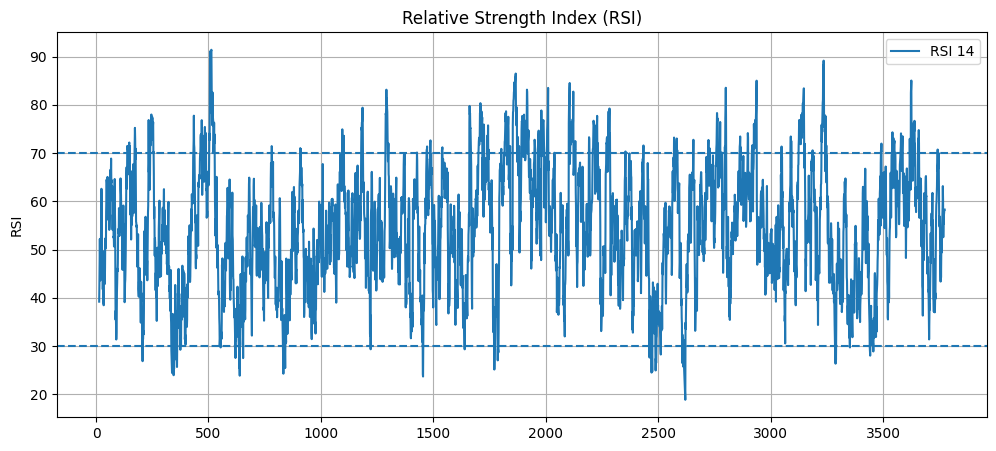

In [28]:
fig, axes = plt.subplots(1,1,figsize=(12, 5),sharex=True)
axes.plot(df.index, df['RSI_14'], label='RSI 14')

# Overbought line
axes.axhline(70, linestyle='--')

# Oversold line
axes.axhline(30, linestyle='--')

axes.set_title('Relative Strength Index (RSI)')
axes.set_ylabel('RSI')
axes.legend()
axes.grid(True)

## Interpretation  - RSI-14

In [29]:
# How many days was price above vs below the EMA?
valid        = df.dropna(subset=['RSI_14'])   # drop the first 49 rows with no EMA yet
above_sma    = (valid['Close'] > valid['RSI_14']).sum()
below_sma    = (valid['Close'] <= valid['RSI_14']).sum()
pct_above    = above_sma / len(valid) * 100

last_close   = valid['Close'].iloc[-1]
last_sma     = valid['RSI_14'].iloc[-1]
current_pos  = 'ABOVE' if last_close > last_sma else 'BELOW'
gap_pct      = abs((last_close - last_sma) / last_sma * 100)

print('WHAT THE MOVING AVERAGE TELLS US')
print('=' * 50)
print(f'  Days price was ABOVE the 14-day RSI : {above_sma}  ({pct_above:.0f}% of the time)')
print(f'  Days price was BELOW the 14-day RSI : {below_sma}  ({100-pct_above:.0f}% of the time)')
print()
print(f'  Last close  : ${last_close:.2f}')
print(f'  RSI 14 now  : ${last_sma:.2f}')
print(f'  Price is currently {current_pos} the average by {gap_pct:.1f}%')
print()
if pct_above > 60:
        print(f'  -> {data_name} spent most of this period above its 14-day average.')
        print(f'     This is a sign of sustained positive momentum — buyers were generally in control.')
elif pct_above > 40:
        print(f'  -> Price moved back and forth around the average.')
        print(f'     The market was indecisive — no clear dominant trend.')
else:
        print(f'  -> {data_name} spent most of this period below its 14-day average.')
        print(f'     This signals sustained selling pressure during the period.')
print()
if current_pos == 'ABOVE':
        print(f'  -> At the end of the period: price is above the RSI — short-term trend is UP.')
else:
        print(f'  -> At the end of the period: price is below the RSI — short-term trend is DOWN.')

WHAT THE MOVING AVERAGE TELLS US
  Days price was ABOVE the 14-day RSI : 22  (1% of the time)
  Days price was BELOW the 14-day RSI : 3738  (99% of the time)

  Last close  : $49.50
  RSI 14 now  : $58.31
  Price is currently BELOW the average by 15.1%

  -> NVDA spent most of this period below its 14-day average.
     This signals sustained selling pressure during the period.

  -> At the end of the period: price is below the RSI — short-term trend is DOWN.


## Moving Average Convergence Divergence

In [30]:
macd, macd_signal, macd_hist = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

df['MACD'] = macd
df['MACD_SIGNAL'] = macd_signal
df['MACD_HIST'] = macd_hist

print ('Calculated MACD using TA-Lib.')
df['MACD_HIST'].head(-5)    


Calculated MACD using TA-Lib.


0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
3764    0.042213
3765    0.163216
3766    0.196256
3767    0.106922
3768    0.096625
Name: MACD_HIST, Length: 3769, dtype: float64

## Visualization - MACD

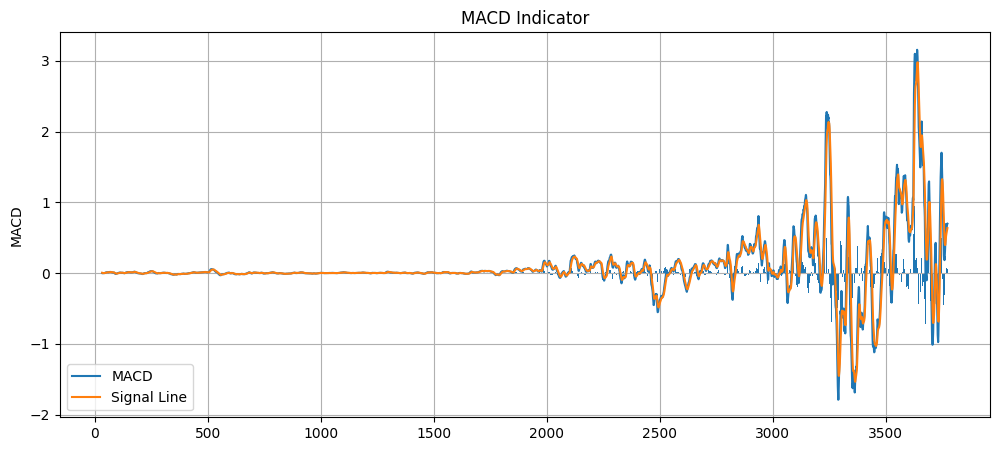

In [31]:
fig, axes = plt.subplots(1,1,figsize=(12, 5),sharex=True)
axes.plot(df.index, df['MACD'], label='MACD')
axes.plot(df.index, df['MACD_SIGNAL'], label='Signal Line')

axes.bar(df.index, df['MACD_HIST'])

axes.set_title('MACD Indicator')
axes.set_ylabel('MACD')
axes.legend()
axes.grid(True)

## Interpretation - MACD

In [32]:
# ============================================
# MACD INTERPRETATION
# ============================================

# Remove rows with NaN MACD values
valid = df.dropna(subset=['MACD', 'MACD_SIGNAL'])

# Count bullish vs bearish days
bullish_days = (valid['MACD'] > valid['MACD_SIGNAL']).sum()
bearish_days = (valid['MACD'] <= valid['MACD_SIGNAL']).sum()

pct_bullish = bullish_days / len(valid) * 100

# Latest values
last_macd = valid['MACD'].iloc[-1]
last_signal = valid['MACD_SIGNAL'].iloc[-1]

# Current MACD position
current_trend = (
    'BULLISH'
    if last_macd > last_signal
    else 'BEARISH'
)

# Gap between MACD and signal line
gap = abs(last_macd - last_signal)

# ============================================
# PRINT INTERPRETATION
# ============================================

print('MACD INTERPRETATION')
print('=' * 50)

print(
    f'  Bullish crossover days : '
    f'{bullish_days} ({pct_bullish:.0f}% of the time)'
)

print(
    f'  Bearish crossover days : '
    f'{bearish_days} ({100-pct_bullish:.0f}% of the time)'
)

print()

print(f'  Current MACD        : {last_macd:.4f}')
print(f'  Current Signal Line : {last_signal:.4f}')

print(
    f'  MACD is currently {current_trend} '
    f'by a difference of {gap:.4f}'
)

print()

# ============================================
# OVERALL TREND INTERPRETATION
# ============================================

if pct_bullish > 60:

    print(
        f'  -> MACD stayed above the signal line '
        f'most of the time.'
    )

    print(
        f'     This indicates sustained bullish momentum '
        f'and strong upward trend conditions.'
    )

elif pct_bullish > 40:

    print(
        f'  -> MACD frequently crossed above and below '
        f'the signal line.'
    )

    print(
        f'     This suggests sideways or indecisive market behavior.'
    )

else:

    print(
        f'  -> MACD remained below the signal line '
        f'for most of the period.'
    )

    print(
        f'     This reflects sustained bearish momentum '
        f'and downward pressure.'
    )

print()

# ============================================
# CURRENT SIGNAL INTERPRETATION
# ============================================

if current_trend == 'BULLISH':

    print(
        f'  -> Current signal: MACD is above the signal line.'
    )

    print(
        f'     This is typically interpreted as a BUY or upward momentum signal.'
    )

else:

    print(
        f'  -> Current signal: MACD is below the signal line.'
    )

    print(
        f'     This is typically interpreted as a SELL or downward momentum signal.'
    )

MACD INTERPRETATION
  Bullish crossover days : 1938 (52% of the time)
  Bearish crossover days : 1803 (48% of the time)

  Current MACD        : 0.6975
  Current Signal Line : 0.6352
  MACD is currently BULLISH by a difference of 0.0624

  -> MACD frequently crossed above and below the signal line.
     This suggests sideways or indecisive market behavior.

  -> Current signal: MACD is above the signal line.
     This is typically interpreted as a BUY or upward momentum signal.


In [33]:
        # Daily returns
df['Daily_Return'] = df['Close'].pct_change()
print('Calculated daily returns as percentage change in closing price.')
df['Daily_Return'].head(-5)

Calculated daily returns as percentage change in closing price.


0            NaN
1       0.018370
2       0.033822
3      -0.059978
4      -0.025522
          ...   
3764    0.011169
3765    0.024279
3766   -0.009445
3767   -0.030098
3768    0.018270
Name: Daily_Return, Length: 3769, dtype: float64

## Interpretation - Daily Returns

In [34]:
print(df.index)
print(df.columns)

RangeIndex(start=0, stop=3774, step=1)
Index(['date', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50',
       'EMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
       'Daily_Return'],
      dtype='str')


In [35]:
# ============================================
# DAILY RETURNS INTERPRETATION
# ============================================

# Remove NaN values
valid_returns = df.dropna(subset=['Daily_Return'])

# Positive vs negative return days
positive_days = (valid_returns['Daily_Return'] > 0).sum()
negative_days = (valid_returns['Daily_Return'] < 0).sum()
neutral_days  = (valid_returns['Daily_Return'] == 0).sum()

pct_positive = positive_days / len(valid_returns) * 100

# Average return
avg_return = valid_returns['Daily_Return'].mean() * 100

# Best and worst returns
best_day_return = valid_returns['Daily_Return'].max() * 100
worst_day_return = valid_returns['Daily_Return'].min() * 100

# Dates now work correctly
best_day_date = valid_returns['Daily_Return'].idxmax().date()
worst_day_date = valid_returns['Daily_Return'].idxmin().date()

# Latest return
latest_return = valid_returns['Daily_Return'].iloc[-1] * 100

# ============================================
# PRINT INTERPRETATION
# ============================================

print('DAILY RETURNS INTERPRETATION')
print('=' * 50)

print(
    f'  Positive return days : '
    f'{positive_days} ({pct_positive:.0f}% of the time)'
)

print(
    f'  Negative return days : '
    f'{negative_days} ({100-pct_positive:.0f}% of the time)'
)

print(f'  Neutral return days  : {neutral_days}')

print()

print(f'  Average daily return : {avg_return:.2f}%')

print(
    f'  Best daily return    : '
    f'{best_day_return:.2f}% on {best_day_date}'
)

print(
    f'  Worst daily return   : '
    f'{worst_day_return:.2f}% on {worst_day_date}'
)

print()

print(f'  Latest daily return  : {latest_return:.2f}%')

print()

# ============================================
# OVERALL INTERPRETATION
# ============================================

if pct_positive > 60:

    print(
        f'  -> The stock generated positive returns '
        f'on most trading days.'
    )

    print(
        f'     This suggests strong bullish market behavior '
        f'during the observed period.'
    )

elif pct_positive > 40:

    print(
        f'  -> Positive and negative return days were relatively balanced.'
    )

    print(
        f'     This indicates mixed or sideways market conditions.'
    )

else:

    print(
        f'  -> Negative return days dominated the period.'
    )

    print(
        f'     This reflects sustained bearish market pressure.'
    )

print()

if latest_return > 0:

    print(
        f'  -> The latest trading session closed with a gain, '
        f'indicating short-term upward momentum.'
    )

else:

    print(
        f'  -> The latest trading session closed with a loss, '
        f'suggesting short-term selling pressure.'
    )

AttributeError: 'int' object has no attribute 'date'

In [ ]:
fig, axes = plt.subplots(1,1,figsize=(12, 5),sharex=True)


## Rolling Volatility

In [ ]:
# Rolling volatility (20-day)
df['Volatility_20'] = df['Daily_Return'].rolling(20).std()
print('Calculated 20-day rolling volatility as standard deviation of daily returns.')
df['Volatility_20'].head(-5)

Calculated 20-day rolling volatility as standard deviation of daily returns.


date
2009-01-02         NaN
2009-01-05         NaN
2009-01-06         NaN
2009-01-07         NaN
2009-01-08         NaN
                ...   
2023-12-15    0.008632
2023-12-18    0.008942
2023-12-19    0.008808
2023-12-20    0.009141
2023-12-21    0.009132
Name: Volatility_20, Length: 3769, dtype: float64

Interpretation - Rolling Volatitlity

In [ ]:
# ============================================
# ROLLING VOLATILITY INTERPRETATION
# ============================================

# Remove NaN values
valid_vol = df.dropna(subset=['Volatility_20'])

# Average volatility
avg_volatility = valid_vol['Volatility_20'].mean() * 100

# Highest and lowest volatility
max_volatility = valid_vol['Volatility_20'].max() * 100
min_volatility = valid_vol['Volatility_20'].min() * 100

# Dates
max_vol_date = valid_vol['Volatility_20'].idxmax().date()
min_vol_date = valid_vol['Volatility_20'].idxmin().date()

# Latest volatility
latest_volatility = valid_vol['Volatility_20'].iloc[-1] * 100

# Compare latest volatility to average
volatility_status = (
    'HIGHER'
    if latest_volatility > avg_volatility
    else 'LOWER'
)

# ============================================
# PRINT INTERPRETATION
# ============================================

print('20-DAY ROLLING VOLATILITY INTERPRETATION')
print('=' * 50)

print(f'  Average volatility : {avg_volatility:.2f}%')

print(
    f'  Highest volatility : '
    f'{max_volatility:.2f}% on {max_vol_date}'
)

print(
    f'  Lowest volatility  : '
    f'{min_volatility:.2f}% on {min_vol_date}'
)

print()

print(f'  Current volatility : {latest_volatility:.2f}%')

print(
    f'  Current volatility is {volatility_status} '
    f'than the historical average.'
)

print()

# ============================================
# OVERALL INTERPRETATION
# ============================================

if avg_volatility > 3:

    print(
        f'  -> The stock experienced high volatility overall.'
    )

    print(
        f'     Large price swings indicate elevated market uncertainty '
        f'and increased trading risk.'
    )

elif avg_volatility > 1.5:

    print(
        f'  -> The stock showed moderate volatility.'
    )

    print(
        f'     Price movements were noticeable but relatively stable.'
    )

else:

    print(
        f'  -> The stock maintained relatively low volatility.'
    )

    print(
        f'     This suggests stable market behavior and lower short-term risk.'
    )

print()

if latest_volatility > avg_volatility:

    print(
        f'  -> Recent volatility has increased compared to normal levels.'
    )

    print(
        f'     This may indicate market uncertainty, news reactions, '
        f'or stronger trading activity.'
    )

else:

    print(
        f'  -> Recent volatility remains below historical average levels.'
    )

    print(
        f'     Market conditions appear relatively calm and stable.'
    )

20-DAY ROLLING VOLATILITY INTERPRETATION
  Average volatility : 1.66%
  Highest volatility : 6.80% on 2020-03-27
  Lowest volatility  : 0.46% on 2010-12-31

  Current volatility : 0.91%
  Current volatility is LOWER than the historical average.

  -> The stock showed moderate volatility.
     Price movements were noticeable but relatively stable.

  -> Recent volatility remains below historical average levels.
     Market conditions appear relatively calm and stable.
